In [6]:
import pickle
import gzip
from pathlib import Path
from numpy import array  # Required so eval() understands stringified numpy arrays

# def convert_txt_to_pickle(txt_path, pkl_path=None, compress=True):
#     """
#     Converts an old text-serialized dictionary file into a compact Pickle file.
    
#     Parameters:
#     - txt_path (str or Path): Path to the existing .txt data file.
#     - pkl_path (str or Path, optional): Path for the output pickle file. 
#                                         If None, automatically replaces .txt with .pkl.gz
#     - compress (bool): Whether to use gzip compression (highly recommended for large files).
    
#     Returns:
#     - Path: The file path of the newly saved pickle file.
#     """
#     txt_path = Path(txt_path)
#     if not txt_path.exists():
#         raise FileNotFoundError(f"Could not find text file at: {txt_path}")
        
#     # Set default output path if none provided
#     if pkl_path is None:
#         ext = ".pkl.gz" if compress else ".pkl"
#         pkl_path = txt_path.with_suffix(ext)
#     else:
#         pkl_path = Path(pkl_path)
        
#     pkl_path.parent.mkdir(parents=True, exist_ok=True)
    
#     print(f"Reading text file: {txt_path.name} (this may take a moment for large files)...")
#     with open(txt_path, 'r') as f:
#         file_content = f.read()
        
#     print("Parsing text content into Python dictionary...")
#     # eval is used here to parse the `str(dict_to_save)` text format back into native types
#     data_dict = eval(file_content)
    
#     print(f"Serializing and saving to: {pkl_path} ...")
#     if compress:
#         with gzip.open(pkl_path, 'wb') as f:
#             pickle.dump(data_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
#     else:
#         with open(pkl_path, 'wb') as f:
#             pickle.dump(data_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
            
#     print("Conversion complete!")
#     return pkl_path

def convert_txt_to_pickle(txt_path, pkl_path=None, compress=True):
    """
    Safely converts a data file (whether it's a binary pickle or text-serialized dict) 
    into a compressed Pickle file (.pkl.gz).
    """
    txt_path = Path(txt_path)
    if not txt_path.exists():
        raise FileNotFoundError(f"Could not find file at: {txt_path}")
        
    if pkl_path is None:
        ext = ".pkl.gz" if compress else ".pkl"
        pkl_path = txt_path.with_suffix(ext)
    else:
        pkl_path = Path(pkl_path)
        
    pkl_path.parent.mkdir(parents=True, exist_ok=True)
    
    # 1. Try reading as a binary pickle first (handles byte 0x80 files)
    try:
        print(f"Attempting to read {txt_path.name} as a binary pickle file...")
        with open(txt_path, 'rb') as f:
            data_dict = pickle.load(f)
        print("Successfully read as a binary pickle!")
    except (pickle.UnpicklingError, Exception):
        # 2. If not binary, fallback to reading as a text-serialized string file
        print("Not a binary pickle. Reading as a text file...")
        with open(txt_path, 'r', encoding='utf-8') as f:
            file_content = f.read()
        data_dict = eval(file_content)
        print("Successfully parsed text content!")
        
    # Re-save cleanly into the compressed format
    print(f"Compressing and saving to: {pkl_path}...")
    if compress:
        with gzip.open(pkl_path, 'wb') as f:
            pickle.dump(data_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
    else:
        with open(pkl_path, 'wb') as f:
            pickle.dump(data_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
            
    print("Conversion complete!")
    return pkl_path

In [11]:
import pathlib
import sys

# Build your original file path
code_name = "[[162,8,14]]"
weak_decoder = "uf"
num_shots = 500000

txt_file = f'/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/data/cluster_norm_statistics/cluster_norm_distributions_code_{code_name}_{weak_decoder}_max_shots_{num_shots}.txt'

# Run the conversion
output_pickle = convert_txt_to_pickle(txt_file)

Attempting to read cluster_norm_distributions_code_[[162,8,14]]_uf_max_shots_500000.txt as a binary pickle file...
Successfully read as a binary pickle!
Compressing and saving to: /Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/data/cluster_norm_statistics/cluster_norm_distributions_code_[[162,8,14]]_uf_max_shots_500000.pkl.gz...
Conversion complete!


stim.Circuit('''
    R 0 1 2
    CX 0 1
    H 2
    DEPOLARIZE2(0.05) 0 1
    Z_ERROR(0.001) 2
    MR 0 1
    MX 2
    DETECTOR rec[-1]
    DETECTOR rec[-2]
''')
[False False]
<bound method PyCapsule.targets_copy of stim.CircuitInstruction('CX', [stim.GateTarget(0), stim.GateTarget(1)], [])>


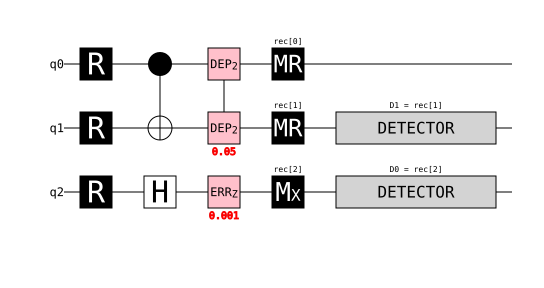

In [1]:
import stim

circuit = stim.Circuit()
circuit.append("R", [0,1,2])
circuit.append("CNOT", [0,1])
circuit.append("H", [2])
circuit.append("DEPOLARIZE2", [0,1], 0.05)
circuit.append("Z_ERROR", [2], [0.001])
# circuit.append("HERALDED_ERASE", 0, 1)
# circuit.append("X_ERROR", 0, 0.5)
circuit.append("MR", [0,1])
circuit.append("MX", 2)
circuit.append("DETECTOR", [stim.target_rec(-1)])
circuit.append("DETECTOR", [stim.target_rec(-2)])

print(repr(circuit))
sampler = circuit.compile_detector_sampler()
sample = sampler.sample(shots=1)[0]
print(sample)

# dem = circuit.detector_error_model(approximate_disjoint_errors=True)

# print(dem)
for inst in circuit.flattened():
    if inst.name == "CX":
        print(inst.targets_copy)
circuit.diagram("timeline-svg")


stim.Circuit('''
    R 0 1 2
    CX 0 1
    DEPOLARIZE1(0.75) 0 1
    H 2
    DEPOLARIZE2(0.05) 0 1
    Z_ERROR(0.001) 2
    MR 0 1
    MX 2
    DETECTOR rec[-1]
    DETECTOR rec[-2]
''')
stim.DetectorErrorModel('''
    error(0.001) D0
    error(0.5) D1
''')
[0. 1.]


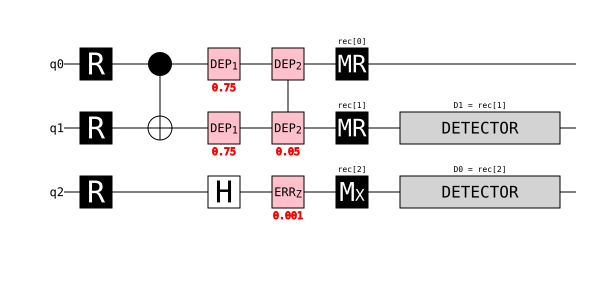

In [20]:
from realtime_decoding.circuits import add_erasures
from realtime_decoding.utils import get_erased_mechanisms_from_DEM

circuit_with_erasures = add_erasures(circuit, p=0.4)
print(repr(circuit_with_erasures))
dem_with_erasures = circuit_with_erasures.detector_error_model()
print(repr(dem_with_erasures))
erased_mechanisms = get_erased_mechanisms_from_DEM(dem_with_erasures)
print(erased_mechanisms)
circuit_with_erasures.diagram("timeline-svg")

In [8]:
import py_wrapper.py_decoder as uf
from quits import detector_error_model_to_matrix
from realtime_decoding.circuits import create_bb_codes_circuit_ionic_model
code_name = "[[54,8,6]]"

# test that this works with UF decoder independently of the decoder switching class
circuit, bb = create_bb_codes_circuit_ionic_model(code_name, p=0.05, num_rounds=1, basis="Z")
circuit_with_erasures = add_erasures(circuit, p=0.5)
dem_with_erasures = circuit_with_erasures.detector_error_model()
erased_mechanisms = get_erased_mechanisms_from_DEM(dem_with_erasures)
h,obs, priors = detector_error_model_to_matrix(dem_with_erasures)
decoder = uf.UFDecoder(h)

sampler = circuit_with_erasures.compile_detector_sampler()
det_events, obs = sampler.sample(shots=1)[0]
print(f"the syndrome is: {det_events} \n")

# 1 : UF decoder with the erasures put in
found_cluster_sizes_erasures, cluster_map_erasures = decoder.ldpc_decode(det_events, erased_mechanisms)
correction_erasures = decoder.correction

# 2: UF decoder results without the erasures put in
found_cluser_sizes_no_erasures, cluster_map_no_erasures = decoder.ldpc_decode(det_events)
correction_no_erasures = decoder.correction

invalid parity check matrix


UnboundLocalError: cannot access local variable 'cnt' where it is not associated with a value

In [2]:
# for toy circuit print to find erasures + see if UF is getting those erasures. If yes, make sims 
# at this point I might as well just do it for the actual decoder switching class ... i am getting too many errors above
from realtime_decoding.decoder_switching_class import decoder_switching_class
code_name = "[[54,8,6]]"

# decode with erasure awareness
decoder_with_erasure = decoder_switching_class(code_name=code_name, 
                               num_rounds=10, 
                               p=0.01, 
                               weak_decoder_option="uf", 
                               strong_decoder_option="tesseract", 
                               num_shots=5,
                               basis="Z",
                               W=3,
                               F=1,
                               decode_with_erasures=True)

num_shots, cluster_norms, switch__times, ler_each_shot = decoder_with_erasure.decode_with_sliding_window_and_decoder_switching_and_erasure(cluster_norm_cutoff=0.001, norm_order=2)
print(f"with erasure decoding: the logical error rate for {num_shots} shots is {sum(ler_each_shot)/ num_shots}")

# decode without erasure awareness
decoder_without_erasure = decoder_switching_class(code_name=code_name,
                                                num_rounds=10,
                                                p=0.01,
                                                weak_decoder_option="uf",
                                                strong_decoder_option="tesseract",
                                                erasure_conversion_rate=0, # should we be doing erasure conversion rate 0? Like i think we should decode on the same circuit to compare with/without erasure
                                                num_shots=5,
                                                basis="Z",
                                                W=3,
                                                F=1,
                                                decode_with_erasures=False)

num_shots, cluster_norms, switch_times, ler_each_shot = decoder_without_erasure.decode_with_sliding_window_and_decoder_switching(cluster_norm_cutoff=0.001, norm_order=2)
print(f"without erasure decoding: the logical error rate for {num_shots} shots is {sum(ler_each_shot)/ num_shots}")


with erasure decoding: the logical error rate for 5 shots is 0.0
Sampling from regular circuit to get observables
9 num_cor_rounds 5 num_shots
0 shot_index (5, 8) obs_flips shape [False  True False False False False False False] obs_flips for this shot
1 shot_index (5, 8) obs_flips shape [ True  True False  True False False  True  True] obs_flips for this shot
2 shot_index (5, 8) obs_flips shape [ True False False False False  True  True False] obs_flips for this shot
3 shot_index (5, 8) obs_flips shape [False False  True  True False False  True  True] obs_flips for this shot
4 shot_index (5, 8) obs_flips shape [ True False False  True False  True  True False] obs_flips for this shot
without erasure decoding: the logical error rate for 5 shots is 0.2


In [11]:
import numpy as np 

p_list = np.logspace(-3, -2.5, 6)[5:]
print(np.round(p_list[0],4))

0.0032


In [18]:
# re-process the cluster dist files now so that I save the switch rates and cutoffs in the pickle files as well ... also change their names
import sys
import os
from pathlib import Path
import numpy as np
import gzip, pickle

from pyparsing import line
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))) #move to level before sims file
min_ord = 3
ps = np.logspace(-min_ord,-2.5,3)
code_name = "[[162,8,14]]"
weak_decoder = "uf"
num_shots = 500_000

if code_name == "[[126,8,10]]" or code_name == "[[144,12,12]]" or code_name == "[[162,8,14]]":
    file_name = sys.path[-1] + f'/data/cluster_norm_statistics/cluster_norm_distributions_code_{code_name}_{weak_decoder}_max_shots_{num_shots}_p_{ps[0]}_to_{ps[-1]}.pkl.gz'
else:
    file_name = sys.path[-1] + f'/data/cluster_norm_statistics/cluster_norm_distributions_code_{code_name}_{weak_decoder}_max_shots_{num_shots}.pkl.gz'

if Path(file_name).name.endswith('.pkl.gz'):
    with gzip.open(file_name, "rb") as file:
        data = pickle.load(file)


# print(data)
cluster_norms = data['cluster_norms']
all_data = np.concatenate(  [cluster_norms[(code_name, p)].flatten() for p in ps] )

gmin = np.min(all_data[all_data > 0])
gmax = np.max(all_data)

cutoffs = np.logspace(np.log10(gmin), np.log10(gmax), 150)

switch_rates = np.zeros((len(ps), len(cutoffs)))

for i, p in enumerate(ps):
    norm_array = cluster_norms[(code_name, p)].flatten()

    for j, g_th in enumerate(cutoffs):
        switch_rates[i, j] = np.mean(norm_array > g_th)

switch_rates = np.ma.masked_equal(switch_rates, 0)

data['switch_rates'] = switch_rates
data['cutoffs'] = cutoffs
data['all_cluster_norms_per_p'] = all_data

txt_to_save = sys.path[-1] + f'/data/cluster_norm_statistics/cluster_norm_distributions_code_{code_name}_{weak_decoder}_max_shots_{num_shots}_p_{np.round(ps[0],min_ord+1)}_to_{np.round(ps[-1], min_ord+1)}.pkl.gz'
file_path = Path(txt_to_save)
file_path.parent.mkdir(parents=True, exist_ok=True)

print(data)
with gzip.open(txt_to_save, "wb") as file:
    pickle.dump(data, file)



{'code_name': '[[162,8,14]]', 'ps': array([0.001     , 0.00177828, 0.00316228]), 'decoder': 'uf', 'norm_order': 2, 'cluster_norms': {('[[162,8,14]]', np.float64(0.001)): array([[0.03327966, 0.02920734],
       [0.02805041, 0.09850956],
       [0.01518633, 0.04406248],
       ...,
       [0.0633387 , 0.01607615],
       [0.03709749, 0.05603546],
       [0.06505637, 0.03470511]], shape=(500000, 2)), ('[[162,8,14]]', np.float64(0.0017782794100389228)): array([[0.14295938, 0.04652491],
       [0.05424787, 0.02611055],
       [0.13168724, 0.05616135],
       ...,
       [0.1751655 , 0.06722958],
       [0.11200573, 0.13337171],
       [0.11611103, 0.06713725]], shape=(138520, 2)), ('[[162,8,14]]', np.float64(0.0031622776601683794)): array([[0.07282161, 0.18742404],
       [0.22812668, 0.10874432],
       [0.2071927 , 0.21895989],
       ...,
       [0.12470925, 0.19426853],
       [0.23886205, 0.21812832],
       [0.19413133, 0.14923559]], shape=(100300, 2))}, 'switch_rates': masked_array(


In [ ]:
# test the lower d codes to see if i get any logical errors at all at the current p 

from realtime_decoding.decoder_switching_class import decoder_switching_class
from simulation_scripts.ler_for_decoder_switching import get_cutoffs_for_input_switch_rate
import numpy as np
code_name = "[[72,12,6]]"
p_switch = 0.01
weak_decoder="uf"
p = np.logspace(-3, -2.5,3)[0]


cutoffs_to_set,_ = get_cutoffs_for_input_switch_rate(target_switch_rate=p_switch, weak_decoder=weak_decoder)
cutoff =cutoffs_to_set[(code_name, p)] 

# decode with erasure awareness
decoder_with_erasure = decoder_switching_class(code_name=code_name, 
                               num_rounds=10, 
                               p=p, 
                               weak_decoder_option="uf", 
                               strong_decoder_option="relay_bp", 
                               num_shots=100,
                               basis="Z",
                               W=3,
                               F=1,
                               decode_with_erasures=True)

num_shots, cluster_norms, switch__times, ler_each_shot = decoder_with_erasure.decode_with_sliding_window_and_decoder_switching_and_erasure(cluster_norm_cutoff=cutoff, norm_order=2)
print(f"with erasure decoding: the logical error rate for {num_shots} shots is {sum(ler_each_shot)/ num_shots}")

# decode without erasure awareness
decoder_without_erasure = decoder_switching_class(code_name=code_name,
                                                num_rounds=10,
                                                p=p,
                                                weak_decoder_option="uf",
                                                strong_decoder_option="relay_bp",
                                                erasure_conversion_rate=0, # should we be doing erasure conversion rate 0? Like i think we should decode on the same circuit to compare with/without erasure
                                                num_shots=100,
                                                basis="Z",
                                                W=3,
                                                F=1,
                                                decode_with_erasures=False)

num_shots, cluster_norms, switch_times, ler_each_shot = decoder_without_erasure.decode_with_sliding_window_and_decoder_switching(cluster_norm_cutoff=cutoff, norm_order=2)
print(f"without erasure decoding: the logical error rate for {num_shots} shots is {sum(ler_each_shot)/ num_shots}")
print(f"epsilon = {1-(1-sum(ler_each_shot)/ num_shots)**(1/10)}")


/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:485: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit early the computation.
/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:583: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit early the computation.
/Users/ariannameinking/Documents/Brown_Research/realtime_decoding_qldpc/src/realtime_decoding/decoder_switching_class.py:687: SyntaxWarning: invalid escape sequence '\s'
  reL_error_tol: relative error tolerance sigma_{p_L}/p_L where sigma_{p_L} = \sqrt{p_L*(1-p_L)/N}. If we reach the rel_error_tol, then we can exit 

with erasure decoding: the logical error rate for 100 shots is 0.04833333333333333
without erasure decoding: the logical error rate for 100 shots is 0.060833333333333336


In [2]:
print(f"epsilon = {1-(1-(0.048))**(1/10)}")

epsilon = 0.00490694583153084
